# Deep JSCC — Grayscale Bottleneck (Layer 5) Reduction Study

**Goal:** train the grayscale Deep-JSCC variant (1-channel luminance input via a learnable
1→3 adapter, then the standard JSCC core) and quantify the transmitted-data saving when the
encoder's final convolution (layer 5, the *bottleneck*) is narrowed:
**c = 8 → 7 → 6 → 5 → 4**. All five models share the same architecture (apart from
layer 5's width), the same training recipe, and the same evaluation protocol, so the
comparison isolates the bottleneck: narrower c → less transmitted data.

**Why grayscale can afford a smaller c.** A grayscale image has n = 96·96 = 9,216 source
values — three times fewer than colour (27,648) — while k = 24·24·c complex symbols is
unchanged. So at equal c the grayscale model has 3× more channel resources per source value;
even c = 4 for grayscale (k/n = 1/4) is more generous than c = 8 was for colour (k/n = 1/6).

**How transmitted data is measured.** Deep JSCC produces no bits, so data is measured in
**channel uses** (complex symbols), not bytes: k = 24·24·c per image, fixed for every image
at every SNR.

| c | k (complex symbols / image) | saving vs c=8 |
|---|---|---|
| 8 | 4,608 | — |
| 7 | 4,032 | −12.5% |
| 6 | 3,456 | −25% |
| 5 | 2,880 | −37.5% |
| 4 | 2,304 | −50% |

## 1. Real-valued weights, complex-valued symbols — how $f_\theta:\mathbb{R}^n \to \mathbb{C}^k$ actually works

The paper defines the encoder as a map $f_\theta:\mathbb{R}^n \to \mathbb{C}^k$ and normalizes
its output by Eq. (1): $z = \sqrt{kP}\,\tilde z / \sqrt{\tilde z^* \tilde z}$, enforcing the
average power constraint $\frac{1}{k}\mathbb{E}[z^*z] \le P$.

**This does *not* require complex-valued weights.** Every layer of the CNN — convolutions,
PReLU activations, the adapter — uses ordinary **real** weights and real arithmetic:

1. The last convolution (layer 5) outputs **2c real feature maps** of size 24×24.
2. These are *paired*: half are interpreted as the **real parts (I)** and half as the
   **imaginary parts (Q)** of c complex symbols per spatial position. The paper states this
   directly: *"by directly transmitting the real and imaginary parts of the channel input
   samples over the I and Q components."*
3. So one complex symbol = 2 real numbers produced by a real CNN. The tensor stays `float32`
   end-to-end; "complex" is the transmission interpretation, not a datatype.

**Consequence for byte counts.** Each complex symbol carries 2 independent real values.
Quantizing each value with Q bits (illustrative Q = 7, per supervisor's suggestion):

$$\text{bytes per image} = k \cdot 2 \cdot Q / 8$$

The factor 2 (I and Q) matters for absolute byte figures; the *relative* saving between
bottleneck widths is independent of Q and of this convention: −12.5% … −50% as in the table
above.

## 2. Setup — load the five grayscale checkpoints

In [1]:
import os, json, math
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets

from gray_model import DeepJSCC_Gray

HERE      = os.getcwd()
DATA      = os.path.join(os.path.dirname(HERE), 'data')
RES       = os.path.join(HERE, 'results')
DEVICE    = 'cuda' if torch.cuda.is_available() else 'cpu'
SNR_TRAIN = 19.0
CS        = [8, 7, 6, 5, 4]
COL       = {8: '#2980B9', 7: '#E67E22', 6: '#16A085', 5: '#8E44AD', 4: '#2C3E50'}
MRK       = {8: 'o', 7: 's', 6: '^', 5: 'D', 4: 'v'}
print('device:', DEVICE)

models, meta = {}, {}
for c in CS:
    ck = torch.load(f'checkpoints/stl10_v2gray_c{c}_demo_snr19_AWGN_best.pth',
                    map_location=DEVICE, weights_only=False)
    m = DeepJSCC_Gray(c=c, channel_type='AWGN', snr=SNR_TRAIN).to(DEVICE)
    m.load_state_dict(ck['state_dict']); m.eval()
    models[c] = m
    meta[c] = {'k': c*24*24, 'best_psnr': ck['best_psnr'], 'epoch': ck['epoch']}
    print(f"c={c}:  k={meta[c]['k']:,} symbols/image   "
          f"train-time best PSNR={ck['best_psnr']:.2f} dB (epoch {ck['epoch']})")

device: cuda


c=8:  k=4,608 symbols/image   train-time best PSNR=32.32 dB (epoch 19)
c=7:  k=4,032 symbols/image   train-time best PSNR=31.63 dB (epoch 17)
c=6:  k=3,456 symbols/image   train-time best PSNR=30.99 dB (epoch 13)
c=5:  k=2,880 symbols/image   train-time best PSNR=30.63 dB (epoch 11)


c=4:  k=2,304 symbols/image   train-time best PSNR=30.16 dB (epoch 12)


## 3. Validation data — 8,000-image STL-10 test set, BT.601 luminance
Same conversion and split as training. PSNR follows the training convention: MSE against the 3-channel replicated grayscale target.

In [2]:
def rgb_to_gray_uint8(chw_uint8):
    a = chw_uint8.astype(np.float32)
    y = 0.299*a[:, 0] + 0.587*a[:, 1] + 0.114*a[:, 2]
    return np.clip(np.round(y), 0, 255).astype(np.uint8)[:, None]

torch.manual_seed(42); np.random.seed(42)
test_full = datasets.STL10(DATA, split='test', download=False)
val_idx = np.random.choice(len(test_full), 8000, replace=False)
val_tensor = torch.from_numpy(rgb_to_gray_uint8(test_full.data[val_idx]))   # (N,1,96,96)
val_loader = DataLoader(TensorDataset(val_tensor), batch_size=128, shuffle=False)
print('val set:', tuple(val_tensor.shape))

val set: (8000, 1, 96, 96)


## 4. PSNR vs channel SNR — sweep all five widths

In [3]:
SNRS = [0, 2, 4, 7, 10, 13, 16, 19, 22, 25]

def eval_at_snr(model, snr):
    model.change_channel('AWGN', snr)
    tot, n = 0.0, 0
    with torch.no_grad():
        for (b,) in val_loader:
            x = b.float().to(DEVICE) / 255.0            # (B,1,H,W)
            target = x.repeat(1, 3, 1, 1)
            r = model(x)                                # (B,3,H,W)
            tot += torch.mean((r - target)**2).item() * x.size(0); n += x.size(0)
    return 10 * math.log10(1.0 / (tot / n))

sweep = {c: [eval_at_snr(models[c], s) for s in SNRS] for c in CS}
for c in CS:
    print(f'c={c}:', '  '.join(f'{p:.2f}' for p in sweep[c]))

c=8: 21.32  23.18  24.93  27.32  29.29  30.76  31.73  32.32  32.64  32.82
c=7: 21.22  23.04  24.76  27.06  28.91  30.25  31.12  31.63  31.91  32.06
c=6: 21.42  23.26  24.95  27.12  28.77  29.90  30.59  30.99  31.20  31.31
c=5: 20.40  22.21  23.91  26.19  28.01  29.31  30.14  30.63  30.90  31.04
c=4: 19.80  21.65  23.39  25.69  27.52  28.84  29.67  30.16  30.43  30.57


## 5. Comparison chart — five bottleneck widths (grayscale)

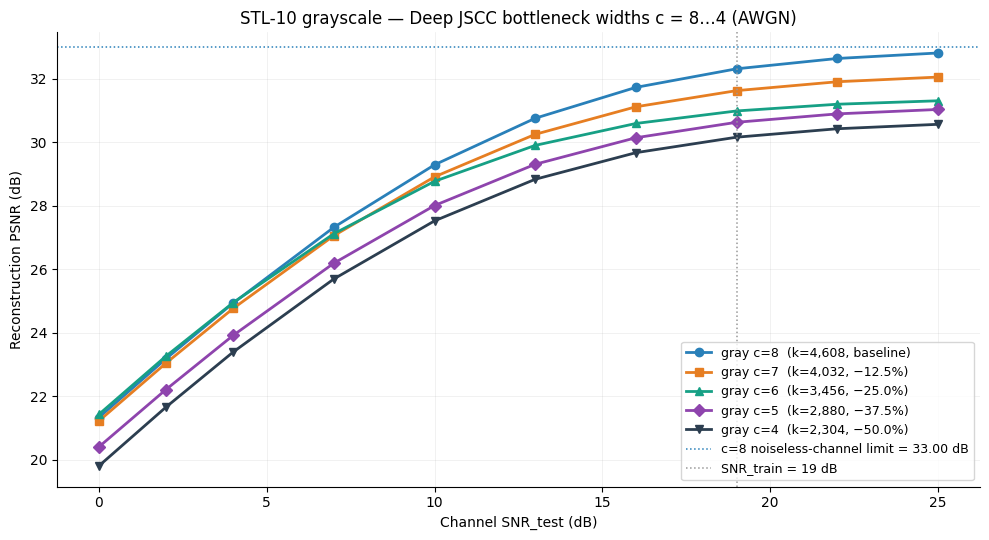

In [4]:
noiseless_c8 = eval_at_snr(models[8], 100.0)
models[8].change_channel('AWGN', SNR_TRAIN)

fig, ax = plt.subplots(figsize=(10, 5.5))
for c in CS:
    ax.plot(SNRS, sweep[c], color=COL[c], marker=MRK[c], ms=6, lw=2,
            label=f'gray c={c}  (k={meta[c]["k"]:,}, −{100*(1-c/8):.1f}%)' if c != 8
                  else f'gray c=8  (k={meta[8]["k"]:,}, baseline)')
ax.axhline(noiseless_c8, color='#2980B9', ls=':', lw=1.1,
           label=f'c=8 noiseless-channel limit = {noiseless_c8:.2f} dB')
ax.axvline(SNR_TRAIN, color='#999999', ls=':', lw=1.1, label='SNR_train = 19 dB')
ax.set_xlabel('Channel SNR_test (dB)'); ax.set_ylabel('Reconstruction PSNR (dB)')
ax.set_title('STL-10 grayscale — Deep JSCC bottleneck widths c = 8…4 (AWGN)')
ax.grid(alpha=0.25, lw=0.5); ax.legend(frameon=True, fontsize=9, loc='lower right')
for s in ('top', 'right'): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

## 6. Data-size summary — channel uses and quantized bytes
Bytes use the I/Q-aware conversion from Section 1: k × 2 × Q / 8 with Q = 7.

In [5]:
Q = 7
i19 = SNRS.index(19)
print(f"{'model':<8}{'k (symbols)':>12}{'bytes @Q7':>12}{'saving':>9}"
      f"{'PSNR@19':>10}{'vs gray c=8':>13}")
for c in CS:
    byt = meta[c]['k'] * 2 * Q / 8
    sav = '-' if c == 8 else f"-{100*(1-meta[c]['k']/meta[8]['k']):.1f}%"
    dlt = '-' if c == 8 else f"{sweep[c][i19]-sweep[8][i19]:+.2f} dB"
    print(f"{'c='+str(c):<8}{meta[c]['k']:>12,}{byt:>12,.0f}{sav:>9}"
          f"{sweep[c][i19]:>10.2f}{dlt:>13}")

model    k (symbols)   bytes @Q7   saving   PSNR@19  vs gray c=8
c=8            4,608       8,064        -     32.32            -
c=7            4,032       7,056   -12.5%     31.63     -0.69 dB
c=6            3,456       6,048   -25.0%     30.99     -1.33 dB
c=5            2,880       5,040   -37.5%     30.63     -1.69 dB
c=4            2,304       4,032   -50.0%     30.16     -2.16 dB


## 7. Qualitative check — grayscale reconstructions at SNR 19 dB and 4 dB
Displayed reconstruction = channel-mean of the model's 3-channel output.

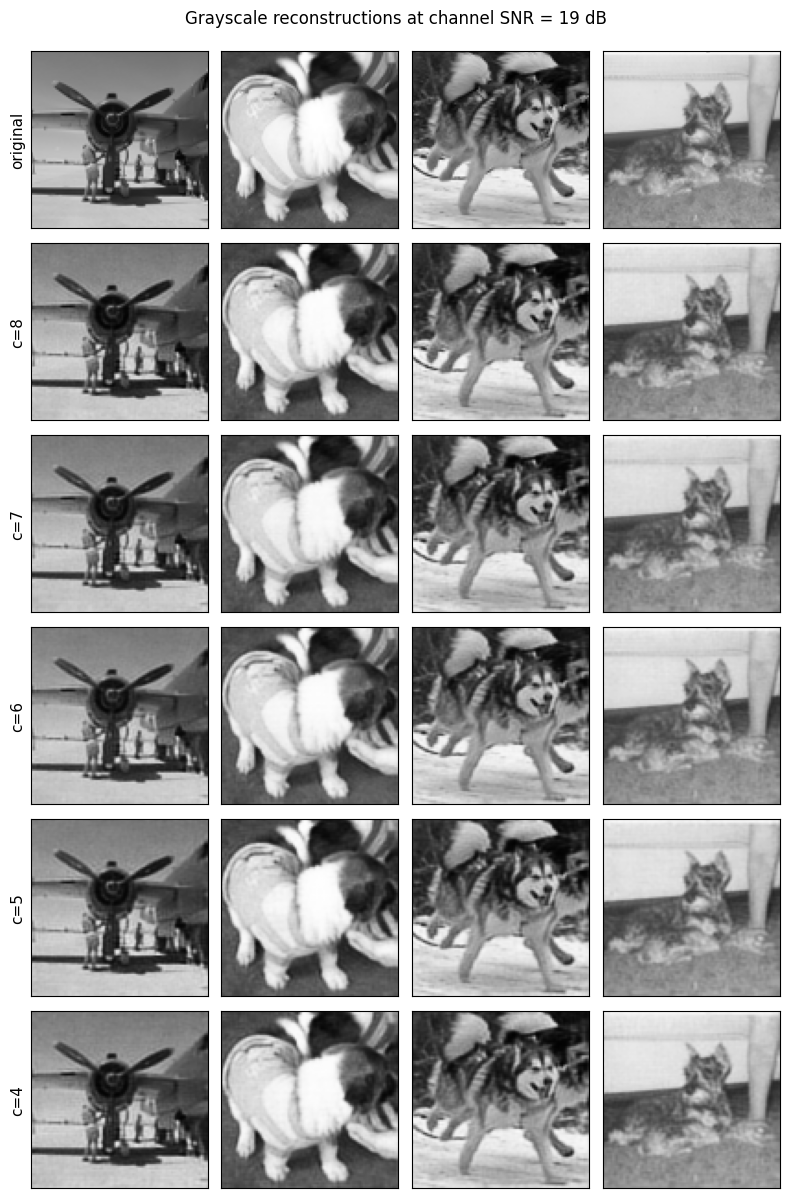

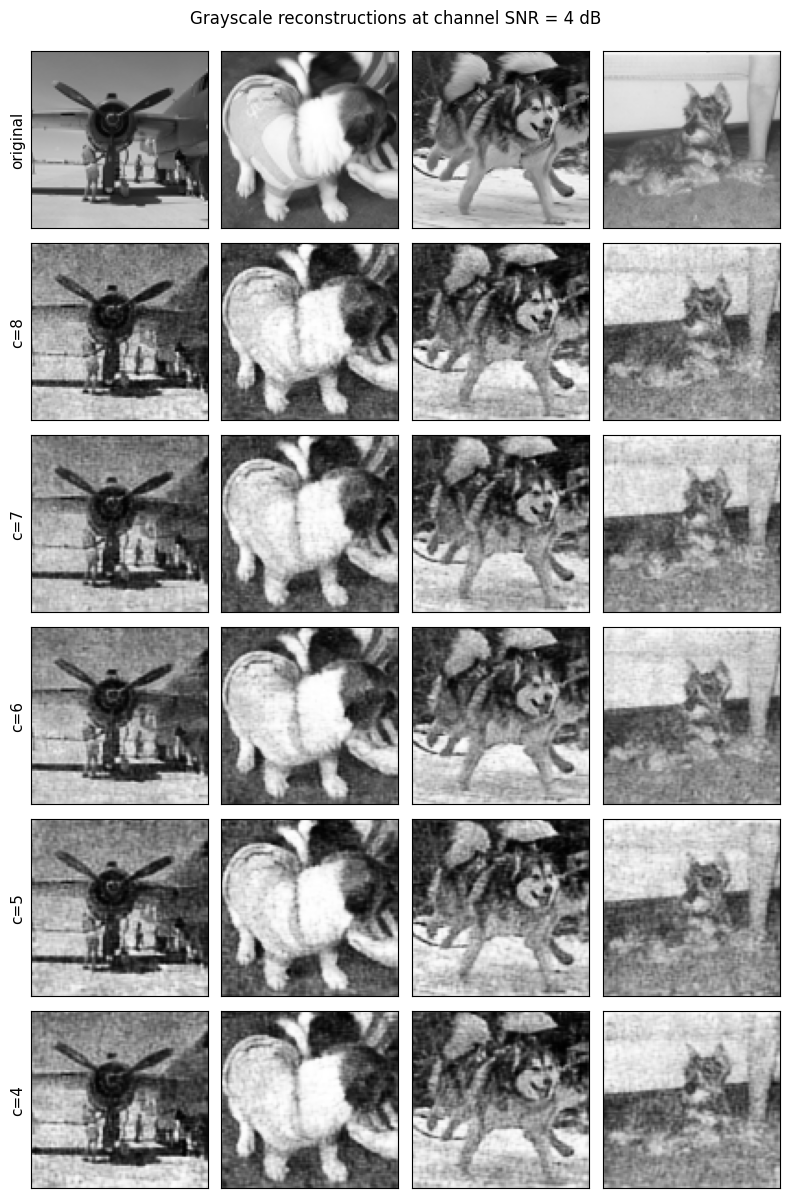

In [6]:
def reconstruct_gray(model, imgs, snr):
    model.change_channel('AWGN', snr)
    with torch.no_grad():
        r = model(imgs.to(DEVICE)).clamp(0, 1).cpu()
    return r.mean(dim=1, keepdim=True)                  # (B,1,H,W)

n_show = 4
show = val_tensor[:n_show].float() / 255.0              # (B,1,H,W)

for snr in (19, 4):
    rows = [show] + [reconstruct_gray(models[c], show, snr) for c in CS]
    titles = ['original'] + [f'c={c}' for c in CS]
    fig, axes = plt.subplots(len(rows), n_show, figsize=(2.0*n_show, 2.0*len(rows)))
    for r, (row, t) in enumerate(zip(rows, titles)):
        for i in range(n_show):
            ax = axes[r, i]
            ax.imshow(row[i, 0].numpy(), cmap='gray', vmin=0, vmax=1)
            ax.set_xticks([]); ax.set_yticks([])
            if i == 0: ax.set_ylabel(t, fontsize=11)
    fig.suptitle(f'Grayscale reconstructions at channel SNR = {snr} dB', y=0.995)
    plt.tight_layout(); plt.show()
for c in CS: models[c].change_channel('AWGN', SNR_TRAIN)

## 8. Training curves — identical recipe, all five widths

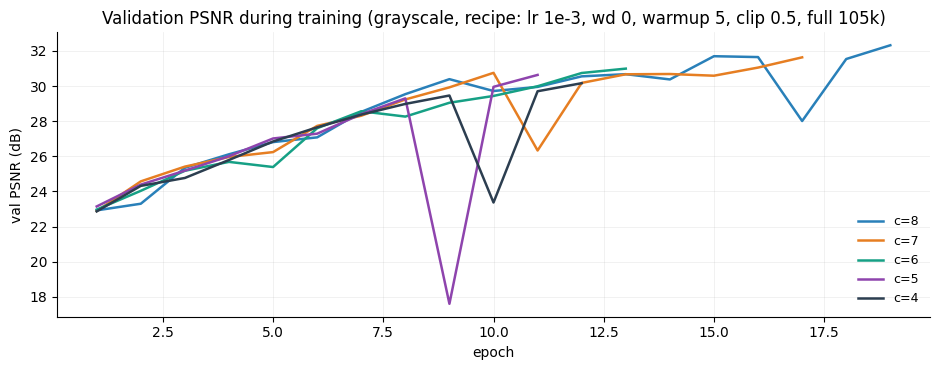

In [7]:
fig, ax = plt.subplots(figsize=(9.5, 3.8))
for c in CS:
    with open(f'train_v2gray_c{c}_demo_history.json') as f:
        h = json.load(f)
    ax.plot(h['epoch'], h['val_psnr'], color=COL[c], lw=1.8, label=f'c={c}')
ax.set_xlabel('epoch'); ax.set_ylabel('val PSNR (dB)')
ax.set_title('Validation PSNR during training (grayscale, recipe: lr 1e-3, wd 0, '
             'warmup 5, clip 0.5, full 105k)')
ax.grid(alpha=0.25, lw=0.5); ax.legend(frameon=False, fontsize=9, loc='lower right')
for s in ('top', 'right'): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

## 9. Conclusions

- Across the five widths, **a wider bottleneck (larger c) yields higher PSNR, while a
  narrower one trades quality for a large, fixed data saving** (Section 6 table).
- Because a grayscale source has 3× fewer values than colour, the bottleneck can be pushed
  much further than in the colour study: **c = 4 halves the transmitted data**
  (2,304 symbols vs 4,608) while remaining in the ≈ 30 dB regime.
- Transmitted data is measured in channel uses (k = 24·24·c complex symbols, fixed per image
  at every SNR); byte figures, when needed, use k × 2 × Q / 8 (I and Q components, Q bits per
  real value) — the relative savings are independent of that convention.
- All weights are real numbers; the "complex" output is the I/Q pairing of the 2c real feature
  maps of layer 5 (Section 1).